In [1]:
pip install yfinace

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement yfinace (from versions: none)
ERROR: No matching distribution found for yfinace


In [2]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime 

plt.style.use('fivethirtyeight')

In [4]:
end=datetime.now()
start=datetime(end.year-15,end.month,end.day)
stock='BTC-USD'
stock_data=yf.download(stock,start=start,end=end)

C:\Users\Soham Rajapurkar\AppData\Local\Temp\ipykernel_22132\2595421129.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data=yf.download(stock,start=start,end=end)
[*********************100%***********************]  1 of 1 completed


In [5]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [6]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2025-10-26,114472.445312,115260.906250,111268.484375,111639.054688,41708524143
2025-10-27,114119.328125,116273.312500,113882.289062,114479.851562,61761358733
2025-10-28,112956.164062,116078.984375,112291.679688,114129.085938,64528066504
2025-10-29,110055.304688,113642.726562,109368.718750,112921.328125,62192043469
2025-10-30,110818.648438,110982.585938,108372.875000,110066.000000,70276292608


In [7]:
stock_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,4062.000000,4062.000000,4062.000000,4062.000000,4.062000e+03
mean,25842.103288,26341.047332,25266.110691,25816.019187,2.105768e+10
std,30805.361035,31312.142809,30223.881557,30779.929757,2.236436e+10
min,178.102997,211.731003,171.509995,176.897003,5.914570e+06
25%,2565.880066,2632.565063,2486.797485,2555.022522,1.163307e+09
50%,10409.045898,10701.490234,10193.185059,10408.752930,1.676438e+10
75%,40535.349609,41620.351562,39494.126953,40506.502930,3.251746e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


In [8]:
stock_data.describe().T

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Close,BTC-USD,4062.0,2.584210e+04,3.080536e+04,1.781030e+02,2.565880e+03,1.040905e+04,4.053535e+04,1.247525e+05
High,BTC-USD,4062.0,2.634105e+04,3.131214e+04,2.117310e+02,2.632565e+03,1.070149e+04,4.162035e+04,1.261981e+05
Low,BTC-USD,4062.0,2.526611e+04,3.022388e+04,1.715100e+02,2.486797e+03,1.019319e+04,3.949413e+04,1.231960e+05
Open,BTC-USD,4062.0,2.581602e+04,3.077993e+04,1.768970e+02,2.555023e+03,1.040875e+04,4.050650e+04,1.247521e+05
Volume,BTC-USD,4062.0,2.105768e+10,2.236436e+10,5.914570e+06,1.163307e+09,1.676438e+10,3.251746e+10,3.509679e+11


In [9]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4062 entries, 2014-09-17 to 2025-10-30
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   4062 non-null   float64
 1   (High, BTC-USD)    4062 non-null   float64
 2   (Low, BTC-USD)     4062 non-null   float64
 3   (Open, BTC-USD)    4062 non-null   float64
 4   (Volume, BTC-USD)  4062 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 190.4 KB


In [10]:
stock_data.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [11]:
#closed price data 
closing_price=stock_data[['Close']]

In [12]:
closing_price["Close"]

Ticker,BTC-USD
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014
...,...
2025-10-26,114472.445312
2025-10-27,114119.328125
2025-10-28,112956.164062


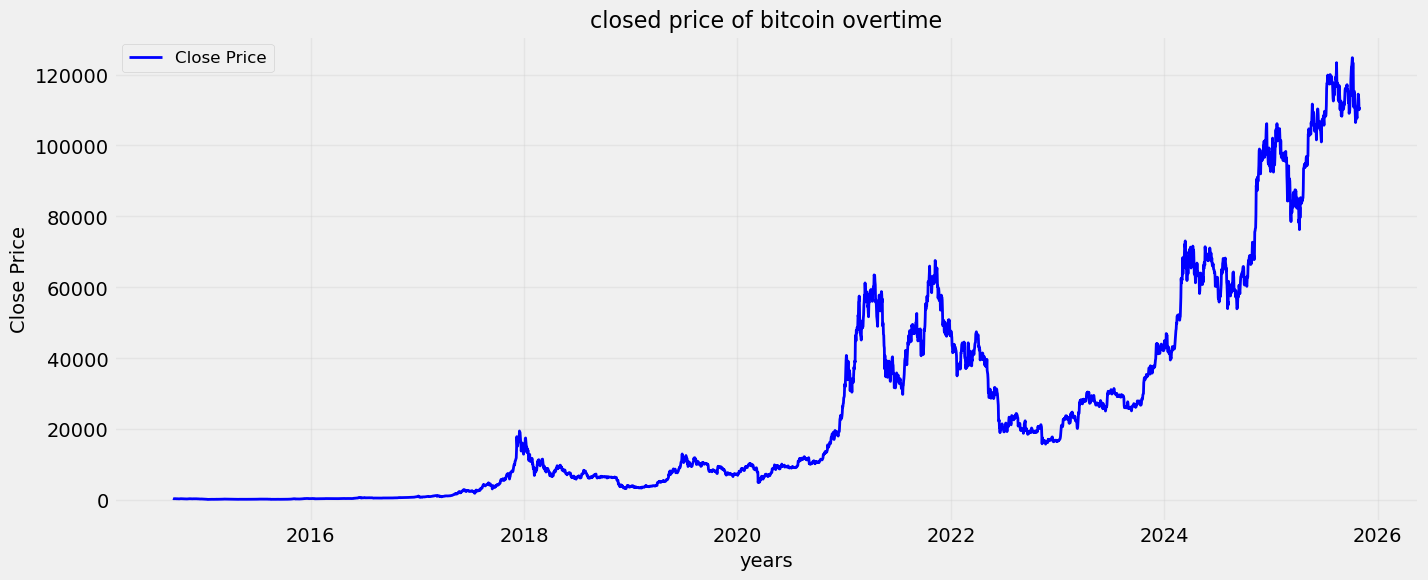

In [13]:
#plot closing price with enchancement
plt.figure(figsize=(15,6))
plt.plot(closing_price.index,closing_price['Close'],label='Close Price',color='blue',linewidth=2)
plt.title("closed price of bitcoin overtime",fontsize=16)
plt.xlabel("years",fontsize=14)
plt.ylabel("Close Price",fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [14]:
#Moving Average
temp_dta=[10,20,30,40,50,60,70,80,90,100]
#moving average for 5 days=>null null null null
print(sum(temp_dta[0:5])/5)

30.0


In [15]:
df1=pd.DataFrame(temp_dta)

In [16]:
df1.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0
9,80.0


In [17]:
for i in range(2014,2025):
    print(i,list(stock_data.index.year).count(i))

2014 106
2015 365
2016 366
2017 365
2018 365
2019 365
2020 366
2021 365
2022 365
2023 365
2024 366


In [18]:
closing_price['MA_365']=closing_price['Close'].rolling(window=365).mean()
closing_price['MA_100']=closing_price['Close'].rolling(window=100).mean()

C:\Users\Soham Rajapurkar\AppData\Local\Temp\ipykernel_22132\153895848.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_365']=closing_price['Close'].rolling(window=365).mean()
C:\Users\Soham Rajapurkar\AppData\Local\Temp\ipykernel_22132\153895848.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_100']=closing_price['Close'].rolling(window=100).mean()


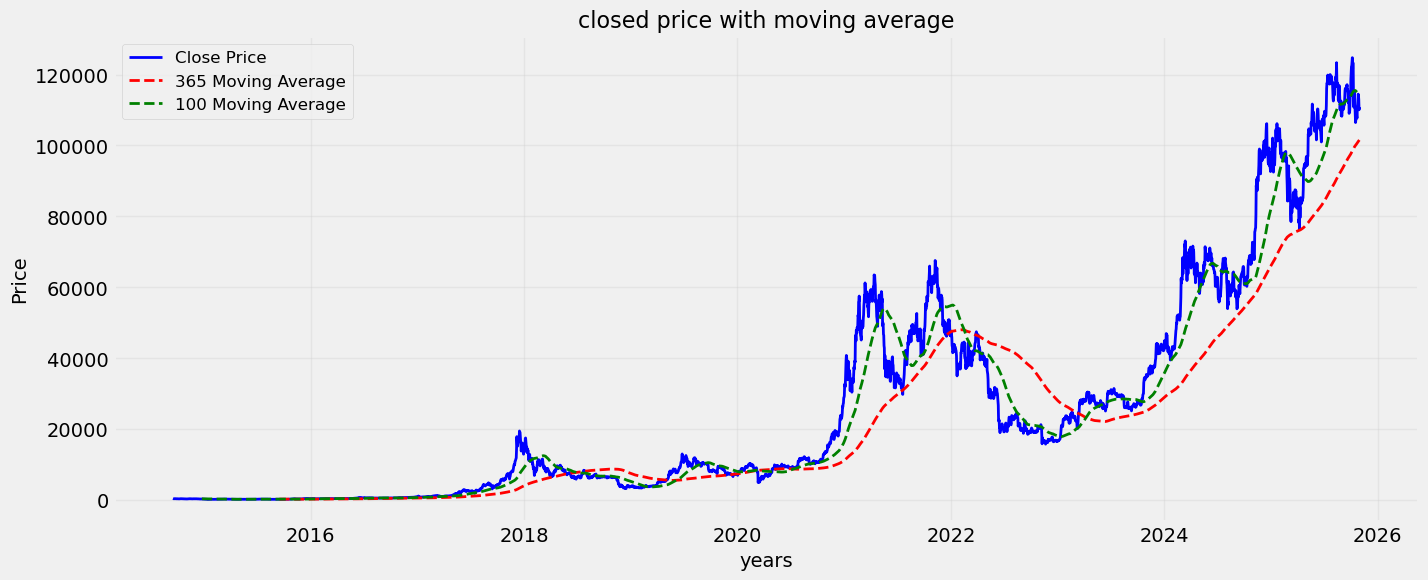

In [19]:
#plot closing price with enchancement
plt.figure(figsize=(15,6))
plt.plot(closing_price.index,closing_price['Close'],label='Close Price',color='blue',linewidth=2)
plt.plot(closing_price.index,closing_price['MA_365'],label='365 Moving Average',color='red',linestyle="--",linewidth=2)
plt.plot(closing_price.index,closing_price['MA_100'],label='100 Moving Average',color='green',linestyle="--",linewidth=2)
 
plt.title("closed price with moving average",fontsize=16)
plt.xlabel("years",fontsize=14)
plt.ylabel("Price",fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [20]:
#LSTM->Long short term memory
#scale the datfrom sklearn.preprocessin





In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(closing_price[['Close']].dropna())

In [22]:
scaled_data

array([[0.00224148],
       [0.00197743],
       [0.00173947],
       ...,
       [0.90530667],
       [0.88202052],
       [0.88814813]])

In [23]:
len(scaled_data)

4062

In [24]:
from keras.models import Sequential
from keras.layers import Dense,LSTM

In [25]:
#prepare data for the lstm
x_data=[]
y_data=[]
base_days=100
for i in range(base_days,len(scaled_data)):
    x_data.append(scaled_data[i-base_days:i])
    y_data.append(scaled_data[i])
x_data=np.array(x_data)
y_data=np.array(y_data)
    

In [26]:
#Split and train the dataset
train_size=int(len(x_data)*0.9)
x_train,y_train=x_data[:train_size],y_data[:train_size]
x_test,y_test=x_data[train_size:],y_data[train_size:]

In [27]:
model=Sequential([
    LSTM(128,return_sequences=True,input_shape=(x_train.shape[1],1)),
    LSTM(64,return_sequences=False),
    Dense(25),
    Dense(1)
])
model.compile(optimizer="adam",loss="mean_squared_error")
model.summary()

C:\Users\Soham Rajapurkar\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.fit(x_train,y_train,batch_size=5,epochs=10)

Epoch 1/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 64s 76ms/step - loss: 0.0013
Epoch 2/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 77s 69ms/step - loss: 2.5953e-04
Epoch 3/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 52s 73ms/step - loss: 1.4484e-04
Epoch 4/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 53s 74ms/step - loss: 1.3335e-04
Epoch 5/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 54s 75ms/step - loss: 1.2053e-04
Epoch 6/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 80s 73ms/step - loss: 1.1557e-04
Epoch 7/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 81s 72ms/step - loss: 1.1074e-04
Epoch 8/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 81s 70ms/step - loss: 1.0751e-04
Epoch 9/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 84s 72ms/step - loss: 1.0040e-04
Epoch 10/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 53s 74ms/step - loss: 1.0615e-04


In [29]:
prediction=model.predict(x_test)
inv_predictions=scaler.inverse_transform(prediction)
inverse_y_test=scaler.inverse_transform(y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step


In [30]:
prediction

array([[0.53366786],
       [0.5314088 ],
       [0.5119996 ],
       [0.49170518],
       [0.4906391 ],
       [0.49198315],
       [0.50295466],
       [0.5029382 ],
       [0.50887614],
       [0.5038224 ],
       [0.5029805 ],
       [0.49010903],
       [0.48781082],
       [0.50608385],
       [0.5121594 ],
       [0.5089886 ],
       [0.53581136],
       [0.54360354],
       [0.5479435 ],
       [0.54581326],
       [0.55451834],
       [0.5537594 ],
       [0.55919456],
       [0.5450167 ],
       [0.54546946],
       [0.5376897 ],
       [0.5527293 ],
       [0.539354  ],
       [0.542856  ],
       [0.55059916],
       [0.5672414 ],
       [0.5907065 ],
       [0.58607405],
       [0.5676263 ],
       [0.562231  ],
       [0.5610834 ],
       [0.55662906],
       [0.54894054],
       [0.5625226 ],
       [0.6162819 ],
       [0.6157864 ],
       [0.6205875 ],
       [0.6220652 ],
       [0.6544344 ],
       [0.7256488 ],
       [0.7121287 ],
       [0.73587453],
       [0.702

In [31]:
inv_predictions

array([[ 66659.47 ],
       [ 66378.05 ],
       [ 63960.16 ],
       [ 61431.992],
       [ 61299.184],
       [ 61466.62 ],
       [ 62833.39 ],
       [ 62831.34 ],
       [ 63571.055],
       [ 62941.49 ],
       [ 62836.605],
       [ 61233.152],
       [ 60946.855],
       [ 63223.207],
       [ 63980.066],
       [ 63585.066],
       [ 66926.49 ],
       [ 67897.2  ],
       [ 68437.84 ],
       [ 68172.48 ],
       [ 69256.91 ],
       [ 69162.36 ],
       [ 69839.445],
       [ 68073.24 ],
       [ 68129.65 ],
       [ 67160.484],
       [ 69034.04 ],
       [ 67367.82 ],
       [ 67804.08 ],
       [ 68768.68 ],
       [ 70841.87 ],
       [ 73765.03 ],
       [ 73187.945],
       [ 70889.82 ],
       [ 70217.71 ],
       [ 70074.74 ],
       [ 69519.85 ],
       [ 68562.055],
       [ 70254.03 ],
       [ 76951.07 ],
       [ 76889.336],
       [ 77487.44 ],
       [ 77671.516],
       [ 81703.89 ],
       [ 90575.39 ],
       [ 88891.125],
       [ 91849.25 ],
       [ 8773

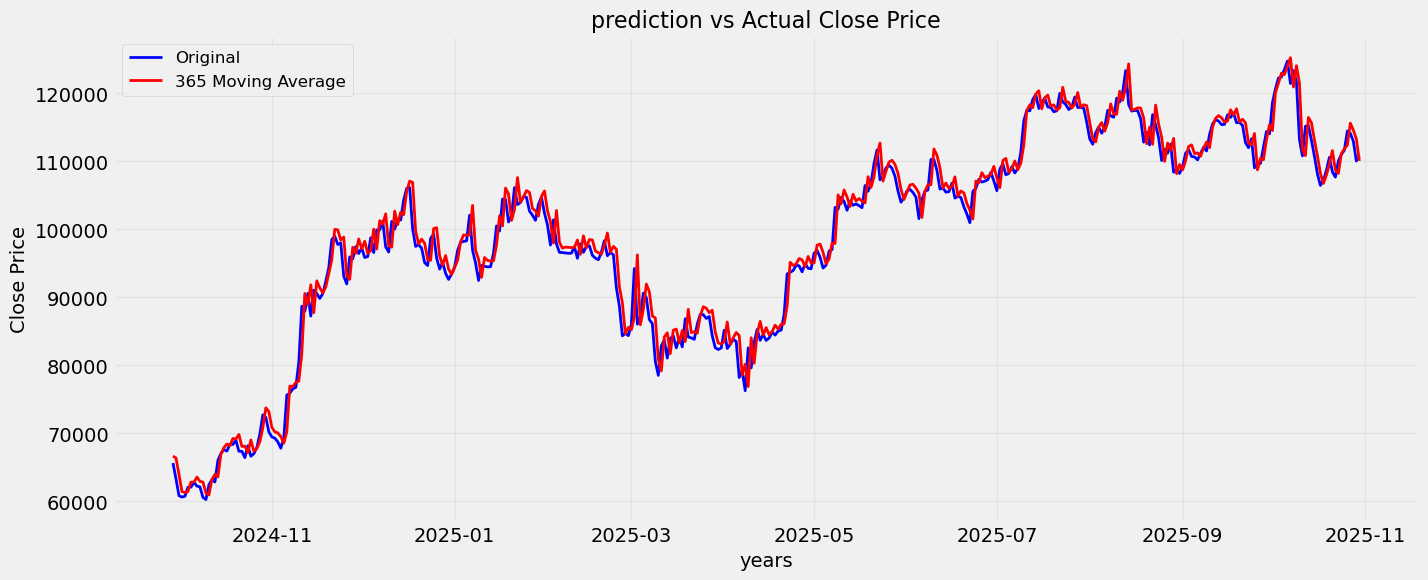

In [32]:
plotting_data=pd.DataFrame(
    {
        'Original':inverse_y_test.flatten(),
        'Prediction':inv_predictions.flatten(),
    }, index=closing_price.index[train_size+base_days:]
)


plt.figure(figsize=(15,6))
plt.plot(plotting_data.index,plotting_data['Original'],label='Original',color='blue',linewidth=2)
plt.plot(plotting_data.index,plotting_data['Prediction'],label='365 Moving Average',color='red',linewidth=2)

plt.title("prediction vs Actual Close Price",fontsize=16)
plt.xlabel("years",fontsize=14)
plt.ylabel("Close Price",fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [33]:
#predict future days
last_100=scaled_data[-100:].reshape(1,-1,1)
future_predictions=[]
for _ in range(10):
    next_days=model.predict(last_100)
    future_predictions.append(scaler.inverse_transform(next_days))
    last_100=np.append(last_100[:,1:,:],next_days.reshape(1,1,-1),axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


In [34]:
future_predictions

[array([[111573.016]], dtype=float32),
 array([[112294.836]], dtype=float32),
 array([[113017.66]], dtype=float32),
 array([[113725.21]], dtype=float32),
 array([[114412.93]], dtype=float32),
 array([[115080.72]], dtype=float32),
 array([[115728.734]], dtype=float32),
 array([[116356.59]], dtype=float32),
 array([[116963.46]], dtype=float32),
 array([[117548.37]], dtype=float32)]

In [35]:
last_100

array([[[0.90186094],
        [0.91543321],
        [0.92229024],
        [0.91482132],
        [0.92193798],
        [0.94175664],
        [0.93526918],
        [0.9337571 ],
        [0.95628498],
        [0.95166676],
        [0.96323784],
        [0.98869376],
        [0.94868166],
        [0.94096558],
        [0.94171212],
        [0.94140476],
        [0.93176594],
        [0.90430338],
        [0.91589133],
        [0.90099493],
        [0.93675712],
        [0.92471807],
        [0.90933852],
        [0.88257478],
        [0.89604708],
        [0.89138647],
        [0.90200455],
        [0.86881982],
        [0.87200856],
        [0.86742207],
        [0.87556084],
        [0.89121407],
        [0.89540935],
        [0.88738516],
        [0.88680223],
        [0.88338027],
        [0.89094942],
        [0.89820462],
        [0.89386277],
        [0.91332754],
        [0.9257874 ],
        [0.93055595],
        [0.92934326],
        [0.92498561],
        [0.92528438],
        [0

In [36]:
future_predictions

[array([[111573.016]], dtype=float32),
 array([[112294.836]], dtype=float32),
 array([[113017.66]], dtype=float32),
 array([[113725.21]], dtype=float32),
 array([[114412.93]], dtype=float32),
 array([[115080.72]], dtype=float32),
 array([[115728.734]], dtype=float32),
 array([[116356.59]], dtype=float32),
 array([[116963.46]], dtype=float32),
 array([[117548.37]], dtype=float32)]

In [37]:
future_predictions=np.array(future_predictions).flatten()




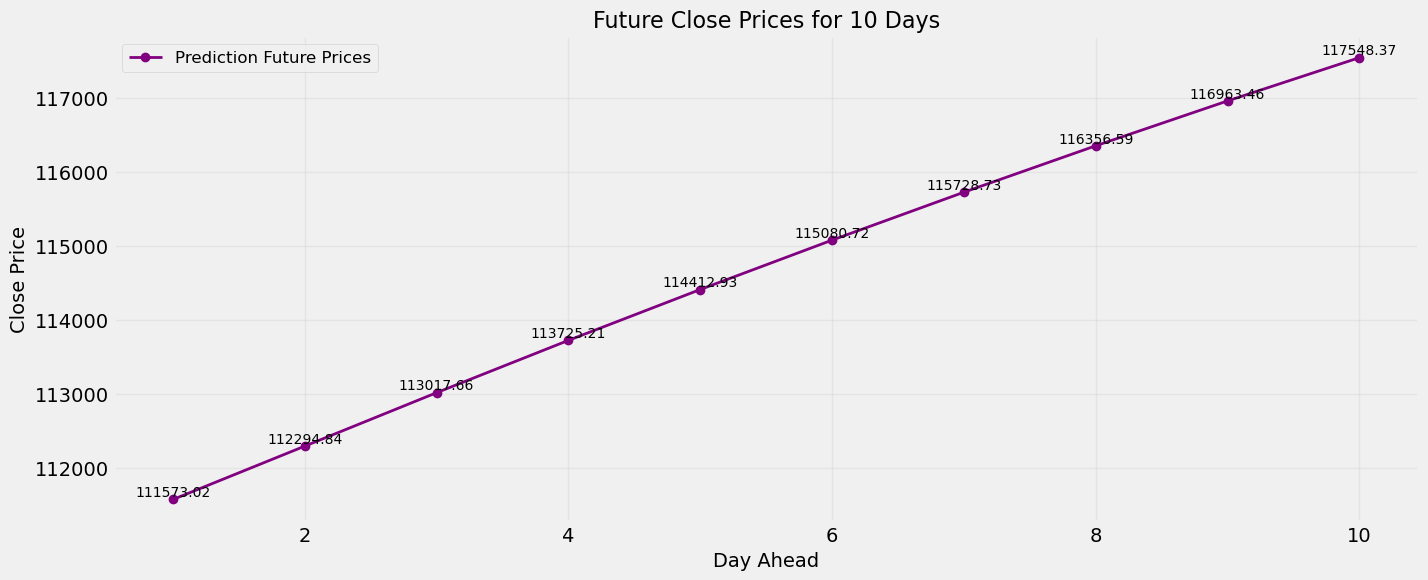

In [38]:


plt.figure(figsize = (15, 6))
plt.plot(range(1, 11), future_predictions, marker="o" ,label = 'Prediction Future Prices', color = 'purple', linewidth =2)

for i, val in enumerate(future_predictions):
    plt.text(i+1,val,  f'{val:.2f}', fontsize = 10, ha = 'center', va = 'bottom', color='black')

plt.title("Future Close Prices for 10 Days", fontsize = 16)
plt.xlabel("Day Ahead", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [39]:
#30 most acurate 

In [40]:
model.save('model.keras')

In [41]:
model.save("model.h5")
